In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd

file_path = r"C:\Users\Admin\hipython\ml\Mall_Customers.csv"
df = pd.read_csv(file_path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# CustomerID 제거, 성별 인코딩
df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [5]:
# StandardScaler로 x 스케일링
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. ID 제거
df = df.drop(columns=['CustomerID'])

# 2. Gender 인코딩
df['Gender'] = (df['Gender'] == 'Male').astype(int)

# 3. 특성 선택
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']]

# 4. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148  0.        ]
 [-1.28103541 -1.73899919  1.19570407  0.        ]
 [-1.3528021  -1.70082976 -1.71591298  0.        ]
 [-1.13750203 -1.70082976  1.04041783  0.        ]
 [-0.56336851 -1.66266033 -0.39597992  0.        ]]


In [9]:
# PCA : 2개의 주성분으로 압축
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)  # (샘플수, 2)

(200, 2)


In [10]:
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

df[['pca_x', 'pca_y']].head()

,pca_x,pca_y
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


In [11]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.44266167 0.33308378]
Cumulative: 0.7757454566976745


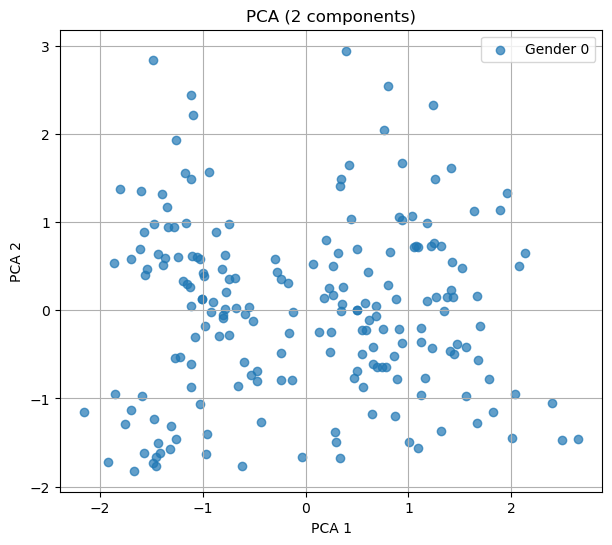

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for g in sorted(df['Gender'].unique()):
    subset = df[df['Gender'] == g]
    plt.scatter(subset['pca_x'], subset['pca_y'], label=f'Gender {g}', alpha=0.7)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA (2 components)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# KMEANS 클러스터링 
from sklearn.cluster import KMeans

k = 6  # 예시(보통 3~8 탐색)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_scaled)
df[['cluster']].head()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,cluster
0,4
1,4
2,5
3,4
4,5


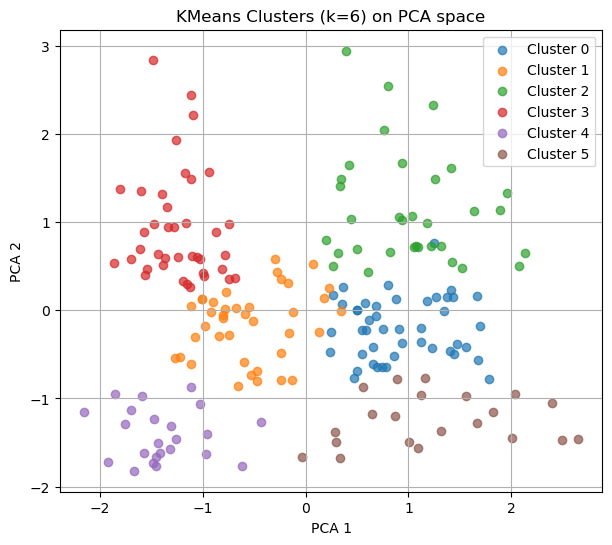

In [19]:
# KMeans 클러스터링 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c]
    plt.scatter(subset['pca_x'], subset['pca_y'], label=f'Cluster {c}', alpha=0.7)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'KMeans Clusters (k={k}) on PCA space')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette score:", score)

Silhouette score: 0.4284167762892593


In [21]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

print(list(zip(ks, inertias, sil_scores)))

[(2, 389.3861889564372, 0.33547192894004574), (3, 295.2122461555489, 0.357793388710272), (4, 205.22514747675913, 0.4039582785148566), (5, 168.24758017556837, 0.41664341513732767), (6, 133.86842085478855, 0.4284167762892593), (7, 117.01155455889813, 0.417231894954916), (8, 103.87329152383714, 0.4082067042807375), (9, 93.09289110041726, 0.41769250624076476), (10, 82.38515364526599, 0.40655411010117015)]


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

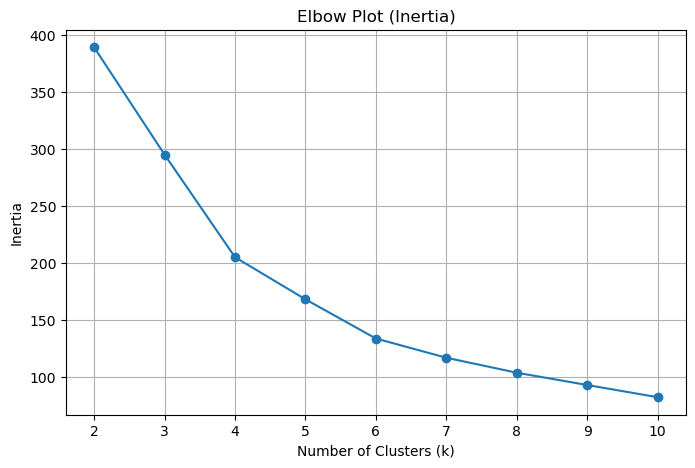

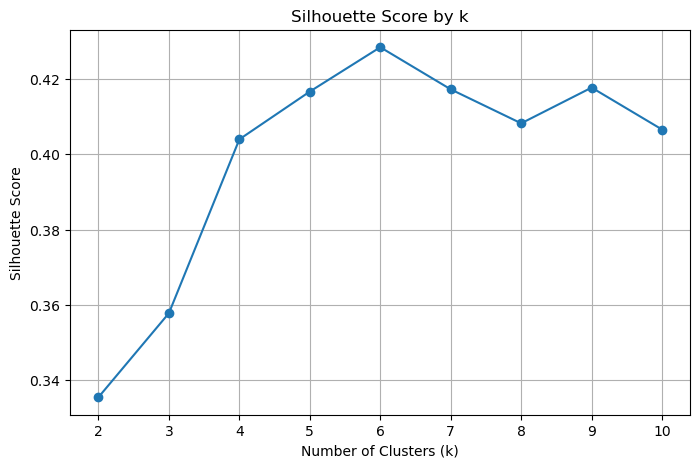

k= 2 | inertia=    389.39 | silhouette=0.3355
k= 3 | inertia=    295.21 | silhouette=0.3578
k= 4 | inertia=    205.23 | silhouette=0.4040
k= 5 | inertia=    168.25 | silhouette=0.4166
k= 6 | inertia=    133.87 | silhouette=0.4284
k= 7 | inertia=    117.01 | silhouette=0.4172
k= 8 | inertia=    103.87 | silhouette=0.4082
k= 9 | inertia=     93.09 | silhouette=0.4177
k=10 | inertia=     82.39 | silhouette=0.4066


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow (Inertia)
plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, marker='o')
plt.xticks(list(ks))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot (Inertia)")
plt.grid(True)
plt.show()

# Silhouette
plt.figure(figsize=(8, 5))
plt.plot(list(ks), sil_scores, marker='o')
plt.xticks(list(ks))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.grid(True)
plt.show()

# 숫자도 같이 확인
for k, inertia, sil in zip(ks, inertias, sil_scores):
    print(f"k={k:2d} | inertia={inertia:10.2f} | silhouette={sil:.4f}")

In [25]:
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# 각 샘플의 실루엣 값
score_samples = silhouette_samples(X_scaled, df['cluster'])

# 평균 실루엣 점수
avg_score = silhouette_score(X_scaled, df['cluster'])

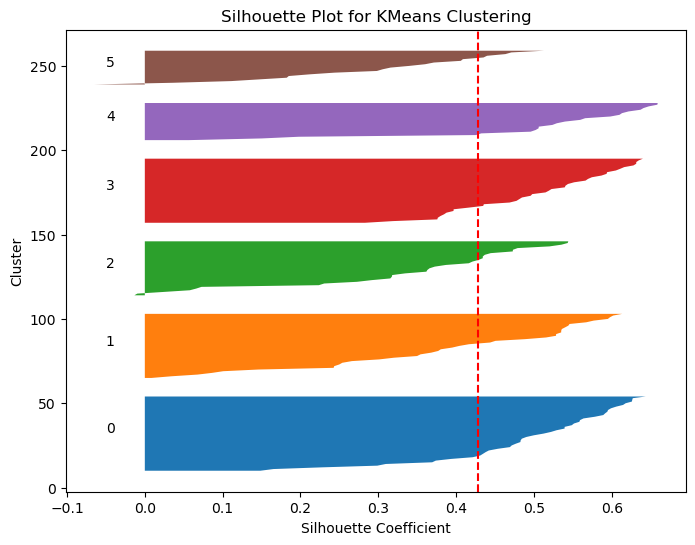

In [26]:
plt.figure(figsize=(8, 6))

y_lower = 10
n_clusters = len(np.unique(df['cluster']))

for i in range(n_clusters):
    cluster_i = score_samples[df['cluster'] == i]
    cluster_i.sort()

    size_cluster_i = cluster_i.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_i
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=avg_score, color="red", linestyle="--")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for KMeans Clustering")
plt.show()